# IDOR Hunting

In [7]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pl.read_parquet('../data/processed/ip_features.parquet')

In [3]:
sus=df.sort('sequential_access_ratio',descending=True)
sus.select(['ip','sequential_access_ratio','unique_invoice_ids','requests_per_minute']).head(20)

ip,sequential_access_ratio,unique_invoice_ids,requests_per_minute
str,f64,u32,f64
"""204.210.158.207""",0.662809,6481,0.093934
"""216.21.168.27""",0.662711,6405,0.093822
"""73.130.229.200""",0.662578,6441,0.094022
"""74.88.210.56""",0.660233,6426,0.093869
"""24.163.83.34""",0.65851,6376,0.092457
…,…,…,…
"""185.208.226.142""",0.424908,820,0.025228
"""157.7.164.178""",0.424674,844,0.024603
"""104.131.11.150""",0.422983,819,0.024566


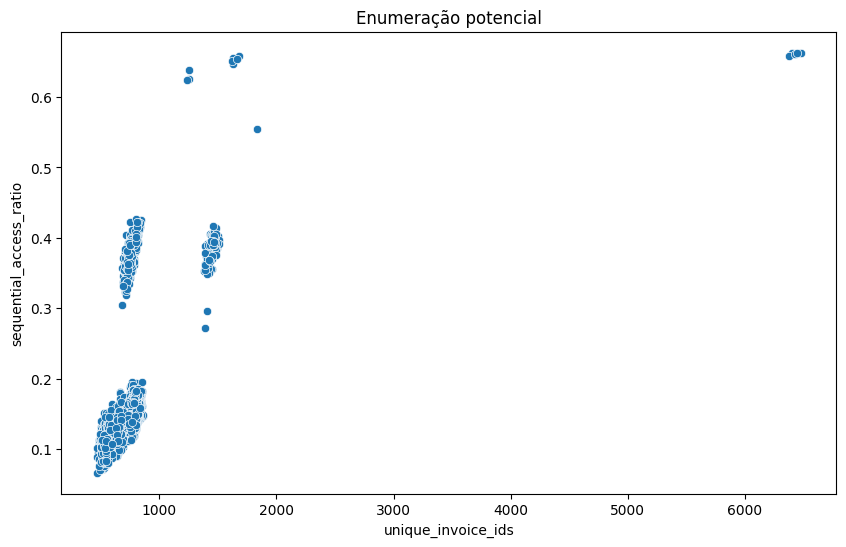

In [4]:
pdf=df.to_pandas()
plt.figure(figsize=(10,6))
sns.scatterplot(data=pdf,x='unique_invoice_ids',y='sequential_access_ratio')
plt.title('Enumeração potencial')
plt.show()

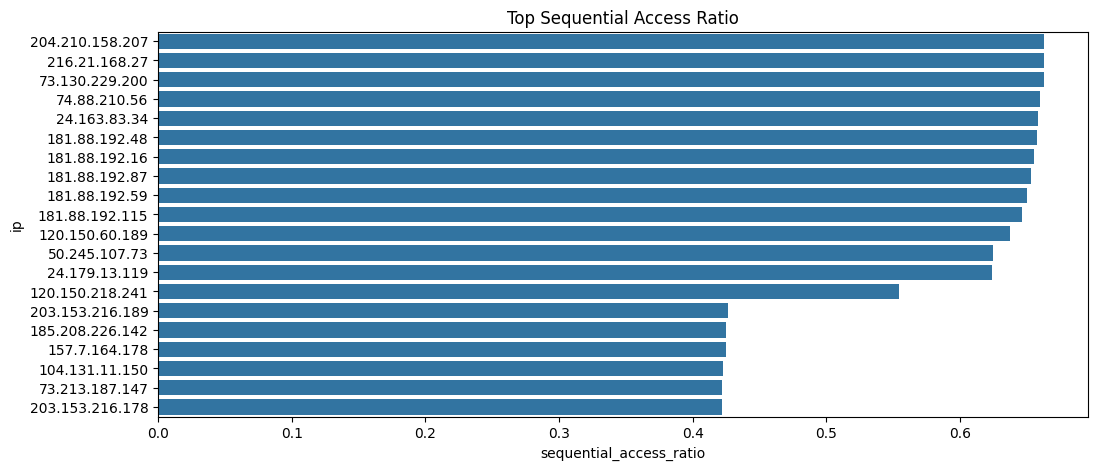

In [5]:
top=sus.head(20).to_pandas()
plt.figure(figsize=(12,5))
sns.barplot(data=top,x='sequential_access_ratio',y='ip')
plt.title('Top Sequential Access Ratio')
plt.show()